# GraphRT Report Figures

Run the setup cell first. Every code cell below generates exactly one figure, shows it inline, and saves it into `Report/Figures/` for reuse in the LaTeX report.

The MiniDataset figures now follow the **same aggregation rule used by the official DeepGCN-RT result tables**: the headline metric for each dataset is the simple average over all rows in that dataset's `summary.csv`. In the current reruns, that means a 10-fold mean for one seed.

In [31]:
from pathlib import Path
import csv
import math
import statistics
import zipfile
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "Train").exists() and (candidate / "Reference").exists() and (candidate / "Report").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root()
RESULT_ROOT = REPO_ROOT / "Train" / "Results" / "DeepGCNRT"
FIG_ROOT = REPO_ROOT / "Report" / "Figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

OFFICIAL_SUMMARY_XLSX = REPO_ROOT / "Reference" / "DeepGCN-RT" / "result" / "result_summary.xlsx"

PAPER_SEVEN = [
    "Eawag_XBridgeC18_364",
    "FEM_lipids_72",
    "FEM_long_412",
    "IPB_Halle_82",
    "LIFE_new_184",
    "LIFE_old_194",
    "UniToyama_Atlantis_143",
]

EXTRA_THREE = [
    "Cao_HILIC_116",
    "FEM_short_73",
    "MTBLS87_147",
]

TRANSFER_ORDER = PAPER_SEVEN + EXTRA_THREE

LABELS = {
    "Eawag_XBridgeC18_364": "Eawag",
    "FEM_lipids_72": "FEM lipids",
    "FEM_long_412": "FEM long",
    "IPB_Halle_82": "IPB Halle",
    "LIFE_new_184": "LIFE new",
    "LIFE_old_194": "LIFE old",
    "UniToyama_Atlantis_143": "UniToyama",
    "Cao_HILIC_116": "Cao HILIC",
    "FEM_short_73": "FEM short",
    "MTBLS87_147": "MTBLS87",
}

SMRT_BASELINE_MAE = {
    "GCN (paper)": 29.40,
    "DNNpwa (paper)": 39.62,
    "GNN-RT (paper)": 39.87,
    "DeepGCN-RT (paper)": 26.55,
}

PAPER_RIKEN_MAE = {
    "Paper TL\n(original split)": 21.45,
    "Paper TL\n(deduplicated)": 24.43,
}


def timestamp_dirs(root):
    root = Path(root)
    if not root.exists():
        return []
    return sorted(path for path in root.iterdir() if path.is_dir() and path.name[:4].isdigit())


def latest_stage_run(stage_name):
    runs = timestamp_dirs(RESULT_ROOT / stage_name)
    if not runs:
        raise FileNotFoundError(f"No timestamped runs found under {RESULT_ROOT / stage_name}")
    return runs[-1]


def read_csv_rows(path):
    with Path(path).open(newline="") as f:
        return list(csv.DictReader(f))


def read_predictions(path):
    rows = read_csv_rows(path)
    y = [float(row["target"]) for row in rows]
    p = [float(row["prediction"]) for row in rows]
    return y, p


def compute_metrics(y, p):
    n = len(y)
    abs_err = [abs(a - b) for a, b in zip(y, p)]
    sq_err = [(a - b) ** 2 for a, b in zip(y, p)]
    y_mean = sum(y) / n
    denom = sum((value - y_mean) ** 2 for value in y)
    abs_sorted = sorted(abs_err)
    medae = abs_sorted[n // 2] if n % 2 else 0.5 * (abs_sorted[n // 2 - 1] + abs_sorted[n // 2])
    mse = sum(sq_err) / n
    return {
        "n": n,
        "mae": sum(abs_err) / n,
        "medae": medae,
        "mape": sum(abs(a - b) / max(abs(a), 1e-8) for a, b in zip(y, p)) / n,
        "mse": mse,
        "rmse": math.sqrt(mse),
        "r2": 0.0 if denom <= 0 else 1.0 - sum(sq_err) / denom,
    }


def parse_scalar(value):
    if value in (None, ""):
        return None
    try:
        if any(token in str(value) for token in [".", "e", "E"]):
            return float(value)
        return int(value)
    except ValueError:
        return value


def normalize_rows(rows):
    return [{key: parse_scalar(value) for key, value in row.items()} for row in rows]


def read_xlsx_first_sheet(path):
    ns = {"a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if "xl/sharedStrings.xml" in zf.namelist():
            root = ET.fromstring(zf.read("xl/sharedStrings.xml"))
            for item in root.findall("a:si", ns):
                parts = [node.text or "" for node in item.findall(".//a:t", ns)]
                shared_strings.append("".join(parts))

        sheet = ET.fromstring(zf.read("xl/worksheets/sheet1.xml"))
        rows = []
        for row in sheet.findall(".//a:sheetData/a:row", ns):
            values = []
            for cell in row.findall("a:c", ns):
                cell_type = cell.get("t")
                value = cell.find("a:v", ns)
                if value is None:
                    values.append("")
                elif cell_type == "s":
                    values.append(shared_strings[int(value.text)])
                else:
                    values.append(value.text)
            rows.append(values)
        return rows


OFFICIAL_TRANSFER_MAE = {}
for row in read_xlsx_first_sheet(OFFICIAL_SUMMARY_XLSX)[1:]:
    OFFICIAL_TRANSFER_MAE[row[0].replace("_result", "")] = float(row[1])


def candidate_dataset_dirs(dataset_name):
    candidates = [
        RESULT_ROOT / "MiniDatasets" / dataset_name,
        RESULT_ROOT / "RIKENMONA" / dataset_name,
    ]
    matches = [path for path in candidates if path.exists()]
    if matches:
        return matches
    fallback = []
    for path in RESULT_ROOT.rglob(dataset_name):
        if path.is_dir() and (path / "summary.csv").exists():
            fallback.append(path)
    return sorted(fallback)


def find_dataset_dir(dataset_name):
    matches = candidate_dataset_dirs(dataset_name)
    if not matches:
        raise FileNotFoundError(f"Could not find a results directory for dataset {dataset_name}")
    for path in matches:
        if path.parent.name == "MiniDatasets":
            return path
    return matches[0]


def load_dataset_summary(dataset_name):
    dataset_dir = find_dataset_dir(dataset_name)
    summary_rows = normalize_rows(read_csv_rows(dataset_dir / "summary.csv"))
    return dataset_dir, summary_rows


def resolve_run_dir(dataset_dir, result_dir):
    if not result_dir:
        return None

    run_dir = Path(result_dir)
    candidates = []
    if run_dir.is_absolute():
        candidates.append(run_dir)
    else:
        candidates.append(REPO_ROOT / run_dir)

    candidates.append(dataset_dir / run_dir.name)

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def aggregate_summary_rows(dataset_dir, rows):
    metric_keys = [
        "test_mae",
        "test_medae",
        "test_mape",
        "test_mse",
        "test_rmse",
        "test_r2",
    ]
    aggregate = {"num_rows": len(rows)}
    for key in metric_keys:
        values = [float(row[key]) for row in rows if row.get(key) is not None]
        aggregate[f"mean_{key}"] = sum(values) / len(values)
        aggregate[f"std_{key}"] = statistics.stdev(values) if len(values) > 1 else 0.0

    test_sizes = []
    for row in rows:
        run_dir = resolve_run_dir(dataset_dir, row.get("result_dir"))
        if run_dir is None:
            continue
        pred_path = run_dir / "test_predictions.csv"
        if pred_path.exists():
            test_sizes.append(len(read_predictions(pred_path)[0]))

    if not test_sizes:
        for run_dir in timestamp_dirs(dataset_dir):
            pred_path = run_dir / "test_predictions.csv"
            if pred_path.exists():
                test_sizes.append(len(read_predictions(pred_path)[0]))

    aggregate["mean_test_size"] = sum(test_sizes) / len(test_sizes) if test_sizes else 0.0
    return aggregate


def load_transfer_metrics(dataset_name):
    dataset_dir, summary_rows = load_dataset_summary(dataset_name)
    aggregate = aggregate_summary_rows(dataset_dir, summary_rows)
    official_mae = OFFICIAL_TRANSFER_MAE[dataset_name]
    return {
        "dataset": dataset_name,
        "label": LABELS.get(dataset_name, dataset_name),
        "result_dir": str(dataset_dir.relative_to(REPO_ROOT)),
        "official_mae": official_mae,
        "our_mean_mae": aggregate["mean_test_mae"],
        "our_std_mae": aggregate["std_test_mae"],
        "mae_gap": aggregate["mean_test_mae"] - official_mae,
        "rows_averaged": aggregate["num_rows"],
        "mean_test_size": aggregate["mean_test_size"],
        "our_mean_r2": aggregate["mean_test_r2"],
    }


SMRT_RUN = latest_stage_run("SMRT")
RIKEN_RUN = latest_stage_run("RIKENMONA")
SMRT_Y, SMRT_P = read_predictions(SMRT_RUN / "test_predictions.csv")
RIKEN_Y, RIKEN_P = read_predictions(RIKEN_RUN / "test_predictions.csv")
SMRT_METRICS = compute_metrics(SMRT_Y, SMRT_P)
RIKEN_METRICS = compute_metrics(RIKEN_Y, RIKEN_P)
MINI_METRICS = [load_transfer_metrics(name) for name in TRANSFER_ORDER]

SEVEN_MEAN_OFFICIAL = sum(item["official_mae"] for item in MINI_METRICS if item["dataset"] in PAPER_SEVEN) / len(PAPER_SEVEN)
SEVEN_MEAN_OURS = sum(item["our_mean_mae"] for item in MINI_METRICS if item["dataset"] in PAPER_SEVEN) / len(PAPER_SEVEN)
TEN_MEAN_OFFICIAL = sum(item["official_mae"] for item in MINI_METRICS) / len(MINI_METRICS)
TEN_MEAN_OURS = sum(item["our_mean_mae"] for item in MINI_METRICS) / len(MINI_METRICS)

print(f"Repo root: {REPO_ROOT}")
print(f"SMRT run: {SMRT_RUN.name} | MAE={SMRT_METRICS['mae']:.2f} s | R2={SMRT_METRICS['r2']:.3f}")
print(f"RIKENMONA run: {RIKEN_RUN.name} | MAE={RIKEN_METRICS['mae']:.2f} s | R2={RIKEN_METRICS['r2']:.3f}")
print(f"Seven paper datasets | official mean MAE={SEVEN_MEAN_OFFICIAL:.2f} s | ours={SEVEN_MEAN_OURS:.2f} s")
print(f"All ten datasets | official mean MAE={TEN_MEAN_OFFICIAL:.2f} s | ours={TEN_MEAN_OURS:.2f} s")

Repo root: /home/jiaokan/GraphRT
SMRT run: 20260324_103037_097_e9b75031 | MAE=26.65 s | R2=0.900
RIKENMONA run: 20260414_061117_376_690e9ba4 | MAE=23.38 s | R2=0.828
Seven paper datasets | official mean MAE=47.54 s | ours=70.48 s
All ten datasets | official mean MAE=55.79 s | ours=84.84 s


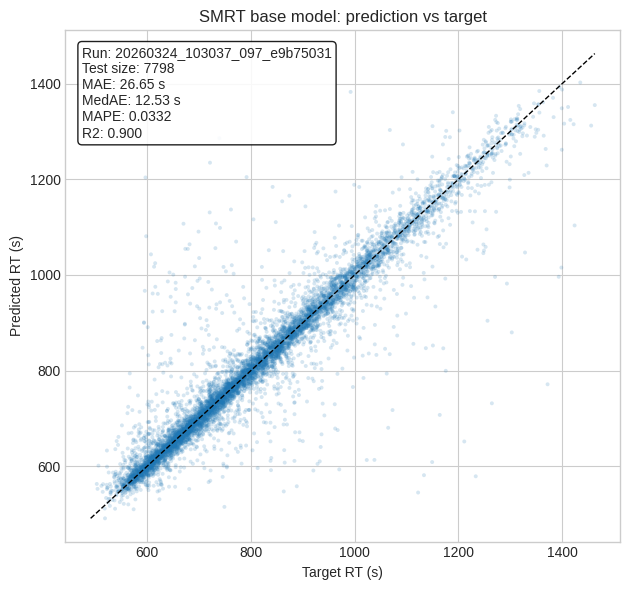

/home/jiaokan/GraphRT/Report/Figures/smrt_base_scatter_report.png


In [32]:
fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.scatter(SMRT_Y, SMRT_P, s=8, alpha=0.18, color="#1f77b4", edgecolors="none")
lo = min(min(SMRT_Y), min(SMRT_P))
hi = max(max(SMRT_Y), max(SMRT_P))
ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.0)
ax.set_title("SMRT base model: prediction vs target")
ax.set_xlabel("Target RT (s)")
ax.set_ylabel("Predicted RT (s)")
summary = (
    f"Run: {SMRT_RUN.name}\n"
    f"Test size: {SMRT_METRICS['n']}\n"
    f"MAE: {SMRT_METRICS['mae']:.2f} s\n"
    f"MedAE: {SMRT_METRICS['medae']:.2f} s\n"
    f"MAPE: {SMRT_METRICS['mape']:.4f}\n"
    f"R2: {SMRT_METRICS['r2']:.3f}"
)
ax.text(0.03, 0.97, summary, transform=ax.transAxes, va="top", ha="left", bbox=dict(boxstyle="round", facecolor="white", alpha=0.88))
out_path = FIG_ROOT / "smrt_base_scatter_report.png"
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()
print(out_path)

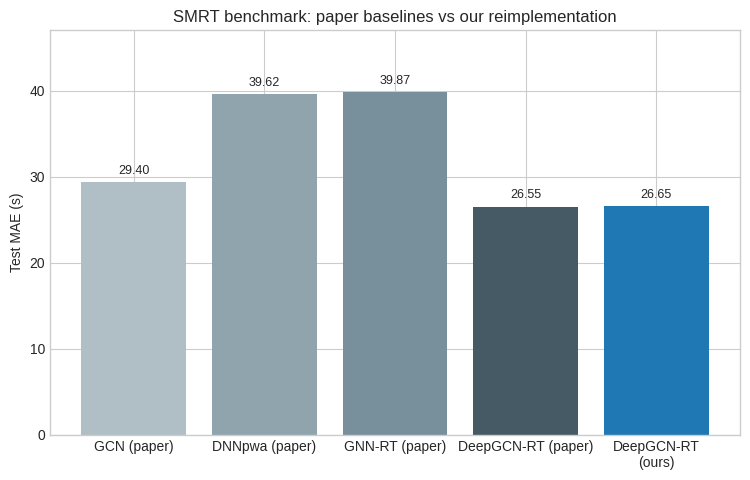

/home/jiaokan/GraphRT/Report/Figures/smrt_mae_comparison_report.png


In [33]:
labels = list(SMRT_BASELINE_MAE) + ["DeepGCN-RT\n(ours)"]
values = list(SMRT_BASELINE_MAE.values()) + [SMRT_METRICS["mae"]]
colors = ["#b0bec5", "#90a4ae", "#78909c", "#455a64", "#1f77b4"]

fig, ax = plt.subplots(figsize=(7.6, 4.9))
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Test MAE (s)")
ax.set_title("SMRT benchmark: paper baselines vs our reimplementation")
ax.set_ylim(0, max(values) * 1.18)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.6, f"{value:.2f}", ha="center", va="bottom", fontsize=9)
out_path = FIG_ROOT / "smrt_mae_comparison_report.png"
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()
print(out_path)

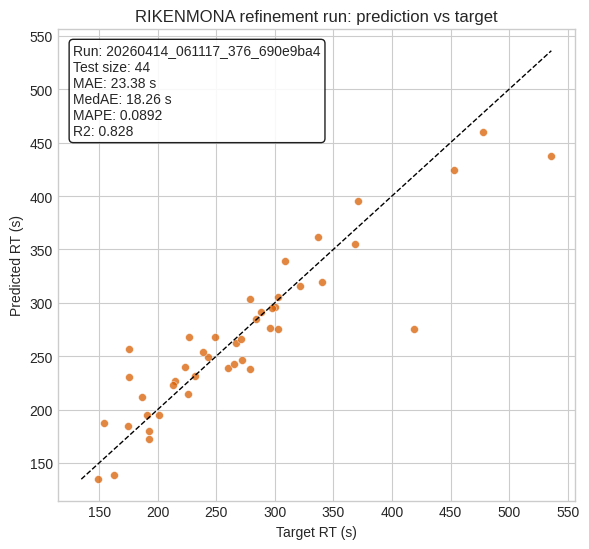

/home/jiaokan/GraphRT/Report/Figures/riken_refined_scatter_report.png


In [34]:
fig, ax = plt.subplots(figsize=(6.0, 5.6))
ax.scatter(RIKEN_Y, RIKEN_P, s=32, alpha=0.75, color="#d95f02", edgecolors="white", linewidth=0.4)
lo = min(min(RIKEN_Y), min(RIKEN_P))
hi = max(max(RIKEN_Y), max(RIKEN_P))
ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.0)
ax.set_title("RIKENMONA refinement run: prediction vs target")
ax.set_xlabel("Target RT (s)")
ax.set_ylabel("Predicted RT (s)")
summary = (
    f"Run: {RIKEN_RUN.name}\n"
    f"Test size: {RIKEN_METRICS['n']}\n"
    f"MAE: {RIKEN_METRICS['mae']:.2f} s\n"
    f"MedAE: {RIKEN_METRICS['medae']:.2f} s\n"
    f"MAPE: {RIKEN_METRICS['mape']:.4f}\n"
    f"R2: {RIKEN_METRICS['r2']:.3f}"
)
ax.text(0.03, 0.97, summary, transform=ax.transAxes, va="top", ha="left", bbox=dict(boxstyle="round", facecolor="white", alpha=0.88))
out_path = FIG_ROOT / "riken_refined_scatter_report.png"
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()
print(out_path)

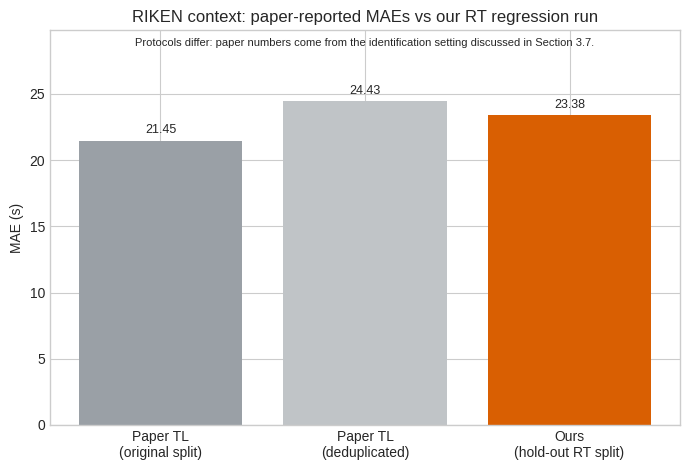

/home/jiaokan/GraphRT/Report/Figures/riken_mae_context_report.png


In [35]:
labels = list(PAPER_RIKEN_MAE) + ["Ours\n(hold-out RT split)"]
values = list(PAPER_RIKEN_MAE.values()) + [RIKEN_METRICS["mae"]]
colors = ["#9aa0a6", "#c0c4c7", "#d95f02"]

fig, ax = plt.subplots(figsize=(7.0, 4.8))
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("MAE (s)")
ax.set_title("RIKEN context: paper-reported MAEs vs our RT regression run")
ax.set_ylim(0, max(values) * 1.22)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=9)
ax.text(0.5, 0.98, "Protocols differ: paper numbers come from the identification setting discussed in Section 3.7.", transform=ax.transAxes, ha="center", va="top", fontsize=8)
out_path = FIG_ROOT / "riken_mae_context_report.png"
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()
print(out_path)

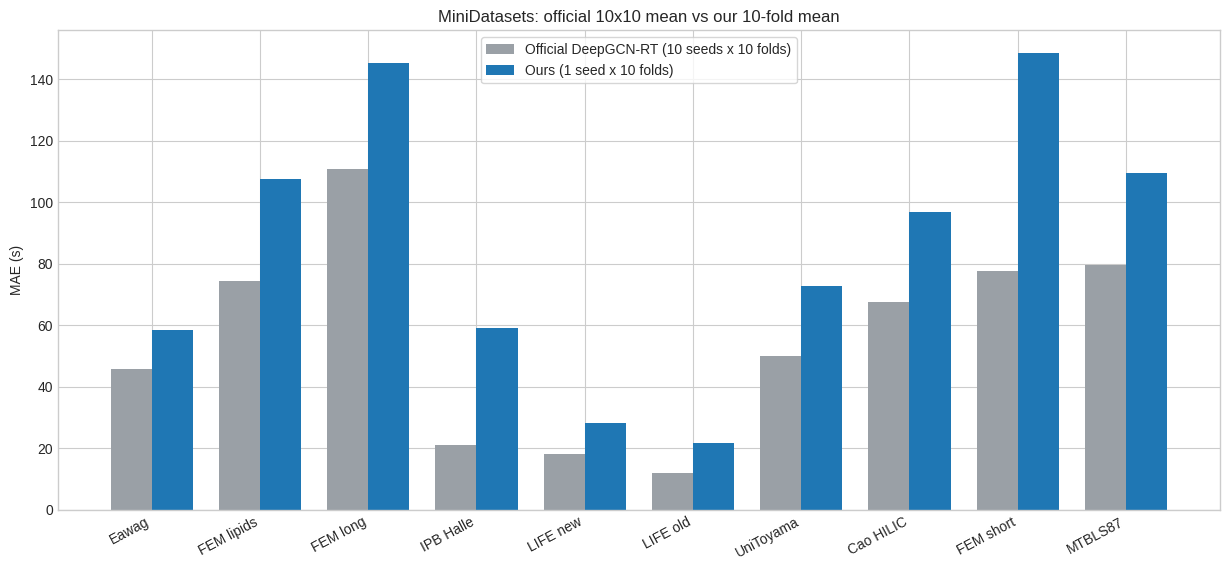

/home/jiaokan/GraphRT/Report/Figures/mini_all_mae_comparison_cv.png


In [36]:
labels = [item["label"] for item in MINI_METRICS]
official = [item["official_mae"] for item in MINI_METRICS]
ours = [item["our_mean_mae"] for item in MINI_METRICS]
positions = list(range(len(MINI_METRICS)))
width = 0.38

fig, ax = plt.subplots(figsize=(12.4, 5.8))
ax.bar([x - width / 2 for x in positions], official, width=width, color="#9aa0a6", label="Official DeepGCN-RT (10 seeds x 10 folds)")
ax.bar([x + width / 2 for x in positions], ours, width=width, color="#1f77b4", label="Ours (1 seed x 10 folds)")
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=28, ha="right")
ax.set_ylabel("MAE (s)")
ax.set_title("MiniDatasets: official 10x10 mean vs our 10-fold mean")
ax.legend(frameon=True)
out_path = FIG_ROOT / "mini_all_mae_comparison_cv.png"
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()
print(out_path)

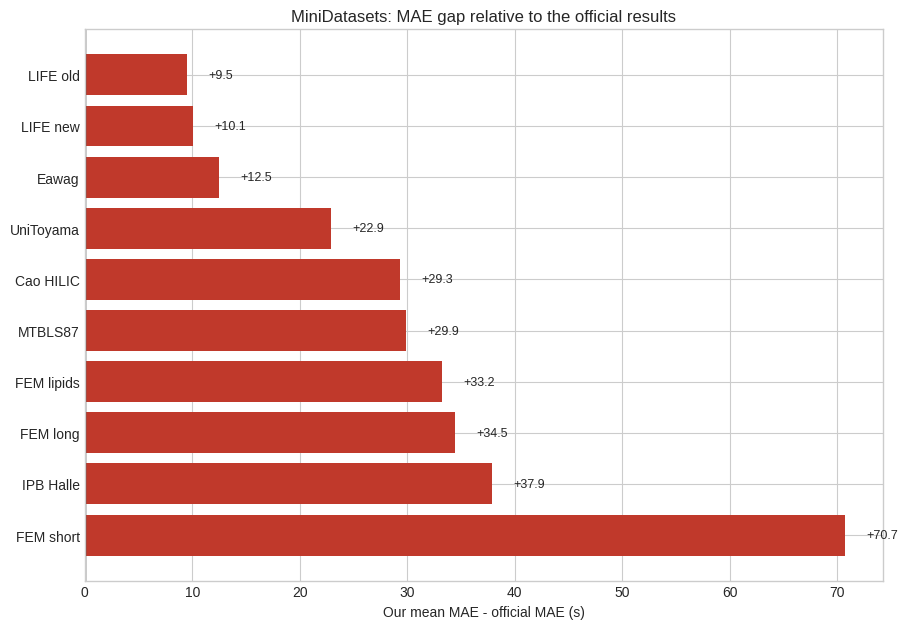

/home/jiaokan/GraphRT/Report/Figures/mini_mae_gap_sorted_cv.png


In [37]:
records = sorted(MINI_METRICS, key=lambda item: item["mae_gap"], reverse=True)
labels = [item["label"] for item in records]
gaps = [item["mae_gap"] for item in records]
colors = ["#c0392b" if gap > 0 else "#2e7d32" for gap in gaps]
y = list(range(len(records)))

fig, ax = plt.subplots(figsize=(9.2, 6.4))
bars = ax.barh(y, gaps, color=colors)
ax.axvline(0.0, color="black", linewidth=1.0)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Our mean MAE - official MAE (s)")
ax.set_title("MiniDatasets: MAE gap relative to the official results")
for yi, gap in zip(y, gaps):
    offset = 2.0 if gap >= 0 else -2.0
    ha = "left" if gap >= 0 else "right"
    ax.text(gap + offset, yi, f"{gap:+.1f}", va="center", ha=ha, fontsize=9)
out_path = FIG_ROOT / "mini_mae_gap_sorted_cv.png"
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()
print(out_path)

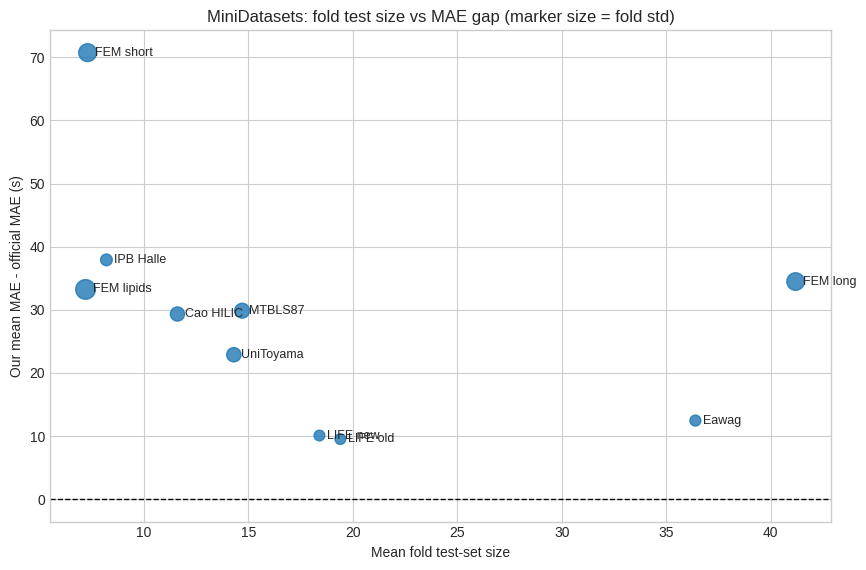

/home/jiaokan/GraphRT/Report/Figures/mini_test_size_vs_gap_cv.png


In [38]:
points = MINI_METRICS

fig, ax = plt.subplots(figsize=(8.8, 5.8))
xs = [item["mean_test_size"] for item in points]
ys = [item["mae_gap"] for item in points]
sizes = [40 + item["our_std_mae"] * 2.5 for item in points]
ax.scatter(xs, ys, s=sizes, color="#1f77b4", marker="o", alpha=0.8)
for item in points:
    ax.text(item["mean_test_size"] + 0.35, item["mae_gap"], item["label"], fontsize=9, va="center")

ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.set_xlabel("Mean fold test-set size")
ax.set_ylabel("Our mean MAE - official MAE (s)")
ax.set_title("MiniDatasets: fold test size vs MAE gap (marker size = fold std)")
out_path = FIG_ROOT / "mini_test_size_vs_gap_cv.png"
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()
print(out_path)